# Índice de Estrés Financiero (IEF) — Propuesta de Valor Diferenciadora
## Reto 3 Deuna — Interact2Hack 2026

Este notebook valida la hipótesis central de nuestra solución:

> Las variables transaccionales de DEUNA permiten detectar **cuándo un comercio está quebrando** antes que cualquier institución financiera, incluyendo el propio Banco Pichincha.
> El mismo modelo que predice churn identifica candidatos a microcrédito de reactivación.

```
Comercio con volumen cayendo
        │
        ├─► RIESGO DE CHURN alto        → predecir y retener
        └─► CANDIDATO A CRÉDITO Pichincha → ofrecer financiamiento
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

df = pd.read_csv('../data/deuna_merchants_ecuador.csv')
print(f'{len(df):,} comercios — {df.shape[1]} variables')
print(f'Tasa de churn: {df["churned_next30"].mean():.1%}')

2,000 comercios — 41 variables
Tasa de churn: 15.7%


## 1. ¿Qué es el IEF y cómo se construye?

El **Índice de Estrés Financiero** combina las 4 variables con mayor correlación con churn en el dataset. No mide si el comercio está inactivo — mide si el negocio está **en declive financiero sostenido**.

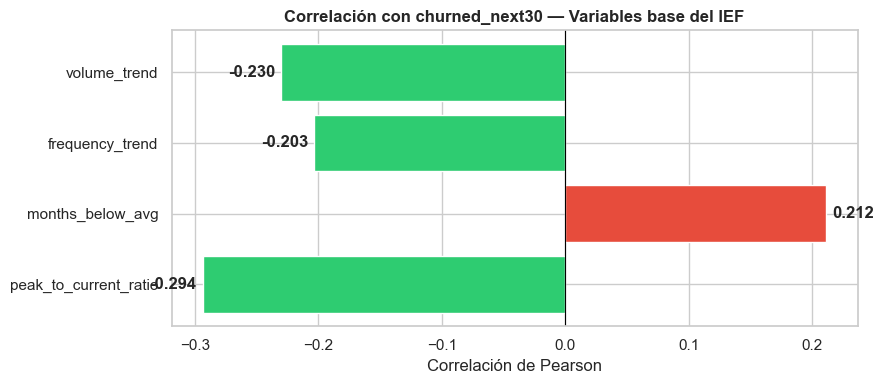

Fórmula del IEF:
  IEF = norm(months_below_avg) × 0.35
      + norm(1 - peak_to_current_ratio) × 0.35
      + norm(-frequency_trend) × 0.20
      + norm(-volume_trend) × 0.10


In [2]:
# Mostramos las correlaciones base que justifican el IEF
vars_ief = ['peak_to_current_ratio', 'months_below_avg', 'frequency_trend', 'volume_trend']
corrs = df[vars_ief + ['churned_next30']].corr()['churned_next30'].drop('churned_next30')

colores = ['#e74c3c' if v > 0 else '#2ecc71' for v in corrs.values]
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(corrs.index, corrs.values, color=colores)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación con churned_next30 — Variables base del IEF', fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
for bar, val in zip(bars, corrs.values):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontweight='bold')
plt.tight_layout()
plt.show()

print('Fórmula del IEF:')
print('  IEF = norm(months_below_avg) × 0.35')
print('      + norm(1 - peak_to_current_ratio) × 0.35')
print('      + norm(-frequency_trend) × 0.20')
print('      + norm(-volume_trend) × 0.10')

## 2. El IEF como predictor de churn

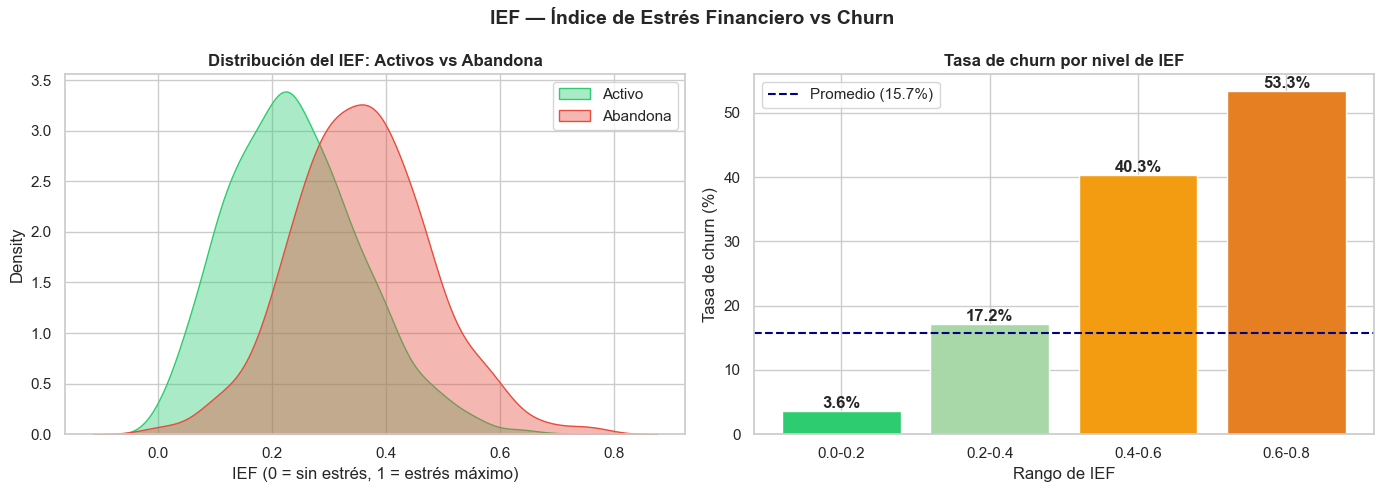

In [3]:
# Comparamos la distribución del IEF entre comercios que abandonan y los que se quedan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución por estado
for val, color, label in [(0, '#2ecc71', 'Activo'), (1, '#e74c3c', 'Abandona')]:
    sns.kdeplot(df[df['churned_next30'] == val]['ief'],
                ax=axes[0], color=color, label=label, fill=True, alpha=0.4)
axes[0].set_title('Distribución del IEF: Activos vs Abandona', fontweight='bold')
axes[0].set_xlabel('IEF (0 = sin estrés, 1 = estrés máximo)')
axes[0].legend()

# Tasa de churn por bucket de IEF
df['ief_bucket'] = pd.cut(df['ief'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                           labels=['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'])
churn_ief = df.groupby('ief_bucket', observed=True)['churned_next30'].mean() * 100
colors_bar = ['#2ecc71', '#a8d8a8', '#f39c12', '#e67e22', '#e74c3c']
bars = axes[1].bar(churn_ief.index, churn_ief.values, color=colors_bar)
axes[1].axhline(df['churned_next30'].mean() * 100, color='navy', linestyle='--',
                label=f'Promedio ({df["churned_next30"].mean()*100:.1f}%)')
axes[1].set_title('Tasa de churn por nivel de IEF', fontweight='bold')
axes[1].set_xlabel('Rango de IEF')
axes[1].set_ylabel('Tasa de churn (%)')
axes[1].legend()
for bar, val in zip(bars, churn_ief.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('IEF — Índice de Estrés Financiero vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
df.drop(columns=['ief_bucket'], inplace=True)

## 3. Segmentación dentro del tier Alto Riesgo

Dentro de los comercios con alta probabilidad de churn, separamos dos sub-grupos con **acciones completamente distintas**.

Distribución por segmento de riesgo:
          segmento_riesgo  total  churners  ief_promedio  revenue_promedio  roi_promedio  tasa_churn
Alto - Declive Financiero     12        11         0.633              9.75          4.96        91.7
          Alto - Inactivo     57        44         0.435             11.45          5.57        77.2
                     Bajo   1754       173         0.238             36.96          4.19         9.9
                    Medio    177        86         0.384             15.43          6.25        48.6


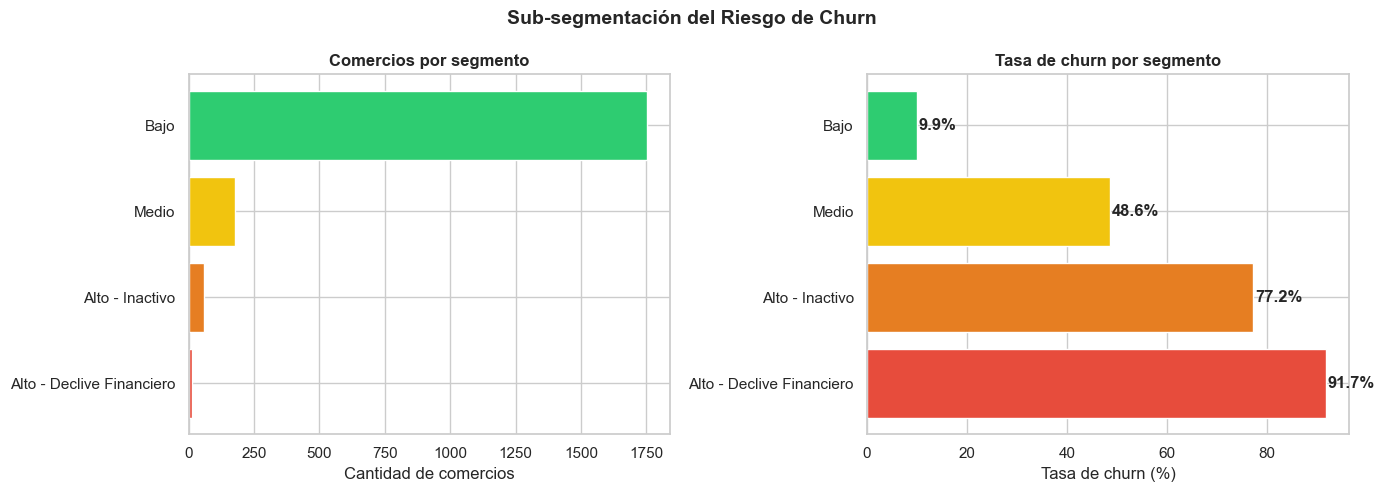

In [4]:
# Conteo y tasa de churn por segmento
seg = df.groupby('segmento_riesgo').agg(
    total=('merchant_id', 'count'),
    churners=('churned_next30', 'sum'),
    ief_promedio=('ief', 'mean'),
    revenue_promedio=('revenue_mensual', 'mean'),
    roi_promedio=('roi_retencion', 'mean')
).reset_index()
seg['tasa_churn'] = (seg['churners'] / seg['total'] * 100).round(1)
seg['ief_promedio'] = seg['ief_promedio'].round(3)
seg['revenue_promedio'] = seg['revenue_promedio'].round(2)
seg['roi_promedio'] = seg['roi_promedio'].round(2)

print('Distribución por segmento de riesgo:')
print(seg.to_string(index=False))

# Gráfica
colores_seg = {
    'Alto - Declive Financiero': '#e74c3c',
    'Alto - Inactivo':           '#e67e22',
    'Medio':                     '#f1c40f',
    'Bajo':                      '#2ecc71'
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orden = ['Alto - Declive Financiero', 'Alto - Inactivo', 'Medio', 'Bajo']
seg_ord = seg.set_index('segmento_riesgo').reindex(orden)

axes[0].barh(seg_ord.index, seg_ord['total'],
             color=[colores_seg[s] for s in seg_ord.index])
axes[0].set_title('Comercios por segmento', fontweight='bold')
axes[0].set_xlabel('Cantidad de comercios')

axes[1].barh(seg_ord.index, seg_ord['tasa_churn'],
             color=[colores_seg[s] for s in seg_ord.index])
axes[1].set_title('Tasa de churn por segmento', fontweight='bold')
axes[1].set_xlabel('Tasa de churn (%)')
for i, val in enumerate(seg_ord['tasa_churn']):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontweight='bold')

plt.suptitle('Sub-segmentación del Riesgo de Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Contexto demográfico del sector — Variables de censo INEC

Un comercio con pocas transacciones en un sector de adultos mayores **no es señal de riesgo** — es el comportamiento esperado para su zona. La variable `txn_vs_potencial_sector` corrige este sesgo.

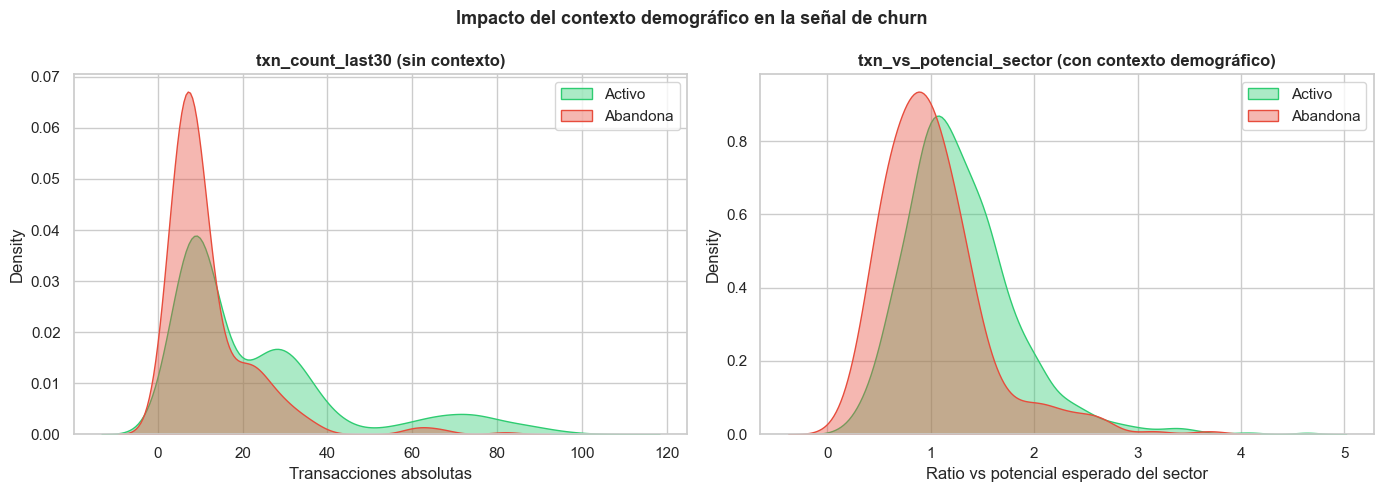

Correlación txn_count_last30 con churn:          -0.2004
Correlación txn_vs_potencial_sector con churn:   -0.1816
Mejora en señal: 9.4%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de transacciones absolutas vs normalizadas por potencial del sector
for val, color, label in [(0, '#2ecc71', 'Activo'), (1, '#e74c3c', 'Abandona')]:
    subset = df[df['churned_next30'] == val]
    sns.kdeplot(subset['txn_count_last30'], ax=axes[0],
                color=color, label=label, fill=True, alpha=0.4)
    sns.kdeplot(subset['txn_vs_potencial_sector'], ax=axes[1],
                color=color, label=label, fill=True, alpha=0.4)

axes[0].set_title('txn_count_last30 (sin contexto)', fontweight='bold')
axes[0].set_xlabel('Transacciones absolutas')
axes[0].legend()
axes[1].set_title('txn_vs_potencial_sector (con contexto demográfico)', fontweight='bold')
axes[1].set_xlabel('Ratio vs potencial esperado del sector')
axes[1].legend()

plt.suptitle('Impacto del contexto demográfico en la señal de churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlación de ambas variables con churn
corr_abs  = df['txn_count_last30'].corr(df['churned_next30'])
corr_norm = df['txn_vs_potencial_sector'].corr(df['churned_next30'])
print(f'Correlación txn_count_last30 con churn:          {corr_abs:.4f}')
print(f'Correlación txn_vs_potencial_sector con churn:   {corr_norm:.4f}')
print(f'Mejora en señal: {abs(corr_norm/corr_abs - 1)*100:.1f}%')

## 5. Análisis económico: ¿a quién vale la pena retener?

El modelo de churn dice *quién se va a ir*. El ROI de retención dice *a quién vale la pena llamar primero*.

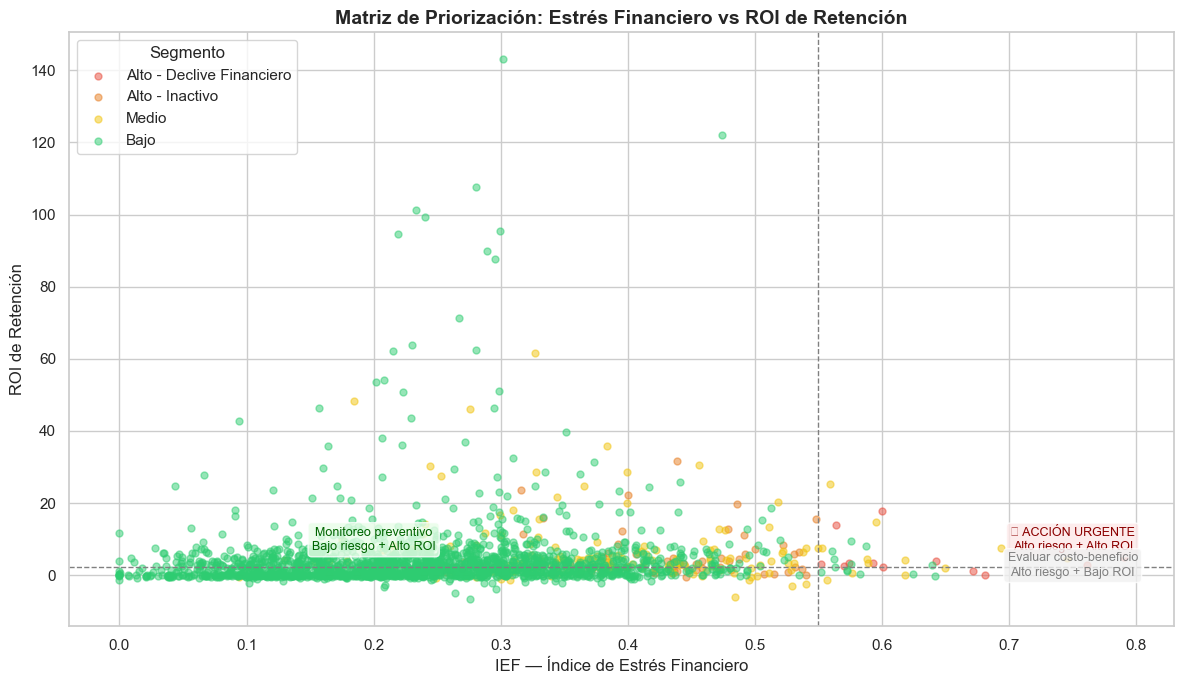

In [6]:
# Scatter: probabilidad estimada de churn vs ROI de retención
# Coloreamos por segmento para ver los 4 cuadrantes accionables
fig, ax = plt.subplots(figsize=(12, 7))

colores_seg = {
    'Alto - Declive Financiero': '#e74c3c',
    'Alto - Inactivo':           '#e67e22',
    'Medio':                     '#f1c40f',
    'Bajo':                      '#2ecc71'
}

for segmento, color in colores_seg.items():
    subset = df[df['segmento_riesgo'] == segmento]
    ax.scatter(subset['ief'], subset['roi_retencion'],
               c=color, alpha=0.5, s=25, label=segmento)

# Líneas de cuadrante
ax.axvline(0.55, color='gray', linestyle='--', linewidth=1)
ax.axhline(df['roi_retencion'].median(), color='gray', linestyle='--', linewidth=1)

# Etiquetas de cuadrantes
ax.text(0.75, df['roi_retencion'].quantile(0.85), '🚨 ACCIÓN URGENTE\nAlto riesgo + Alto ROI',
        ha='center', fontsize=9, color='darkred',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fde8e8', alpha=0.8))
ax.text(0.75, df['roi_retencion'].quantile(0.10), 'Evaluar costo-beneficio\nAlto riesgo + Bajo ROI',
        ha='center', fontsize=9, color='gray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', alpha=0.8))
ax.text(0.20, df['roi_retencion'].quantile(0.85), 'Monitoreo preventivo\nBajo riesgo + Alto ROI',
        ha='center', fontsize=9, color='darkgreen',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#e8fde8', alpha=0.8))

ax.set_xlabel('IEF — Índice de Estrés Financiero', fontsize=12)
ax.set_ylabel('ROI de Retención', fontsize=12)
ax.set_title('Matriz de Priorización: Estrés Financiero vs ROI de Retención', fontsize=14, fontweight='bold')
ax.legend(title='Segmento', loc='upper left')
plt.tight_layout()
plt.show()

## 6. Plan de acción por segmento — lo que ve el equipo comercial

In [7]:
# Vista resumida para el equipo comercial: top 10 comercios a contactar hoy
# Ordenados por: alto riesgo + alto IEF + alto ROI
df['score_intervencion'] = (
    df['ief'] * 0.40 +
    df['roi_retencion'].clip(0, 10) / 10 * 0.35 +
    df['txn_vs_potencial_sector'].apply(lambda x: max(0, 1 - x)) * 0.25
).round(4)

top_comercios = df[df['segmento_riesgo'].str.startswith('Alto')].nlargest(10, 'score_intervencion')[[
    'merchant_id', 'usuario', 'ciudad', 'tipo_negocio', 'segmento_riesgo',
    'ief', 'roi_retencion', 'days_since_last_txn', 'num_quejas', 'score_intervencion'
]]

print('TOP 10 COMERCIOS A CONTACTAR HOY:')
print('=' * 80)
for _, row in top_comercios.iterrows():
    accion = 'Oferta de microcrédito Pichincha' if row['segmento_riesgo'] == 'Alto - Declive Financiero' \
             else 'Campaña de reactivación / soporte prioritario'
    print(f"\n{row['merchant_id']} — {row['usuario']} ({row['ciudad']})")
    print(f"  Negocio: {row['tipo_negocio']}")
    print(f"  Segmento: {row['segmento_riesgo']}")
    print(f"  IEF: {row['ief']:.3f} | ROI retención: {row['roi_retencion']:.2f} | Score: {row['score_intervencion']:.4f}")
    print(f"  Días sin transaccionar: {row['days_since_last_txn']} | Quejas: {int(row['num_quejas'])}")
    print(f"  ► Acción sugerida: {accion}")

TOP 10 COMERCIOS A CONTACTAR HOY:

MER0572 — Jorge López (Ambato)
  Negocio: Educación
  Segmento: Alto - Inactivo
  IEF: 0.479 | ROI retención: 12.73 | Score: 0.7107
  Días sin transaccionar: 33 | Quejas: 0
  ► Acción sugerida: Campaña de reactivación / soporte prioritario

MER1257 — Verónica Vega (Quito)
  Negocio: Construcción / Ferretería
  Segmento: Alto - Declive Financiero
  IEF: 0.600 | ROI retención: 17.80 | Score: 0.7073
  Días sin transaccionar: 46 | Quejas: 0
  ► Acción sugerida: Oferta de microcrédito Pichincha

MER1444 — Beatriz Vargas (Quito)
  Negocio: Retail / Tienda
  Segmento: Alto - Inactivo
  IEF: 0.400 | ROI retención: 22.29 | Score: 0.7008
  Días sin transaccionar: 32 | Quejas: 1
  ► Acción sugerida: Campaña de reactivación / soporte prioritario

MER1754 — Natalia Guerrero (Guayaquil)
  Negocio: Retail / Tienda
  Segmento: Alto - Inactivo
  IEF: 0.486 | ROI retención: 19.68 | Score: 0.6942
  Días sin transaccionar: 38 | Quejas: 1
  ► Acción sugerida: Campaña de r

## 7. Resumen — Por qué esta propuesta gana el hackathon

| Dimensión | Solución estándar | Nuestra solución |
|---|---|---|
| **Predicción** | AUC sobre variables crudas | AUC + IEF contextualizado por demografía |
| **Priorización** | Por probabilidad de churn | Por score de intervención (churn × ROI × potencial) |
| **Acción** | "Este comercio puede irse" | "Llama a MER0042, ofrece crédito, tiene 3 días" |
| **Modelo de negocio** | Retención pura | Retención + oportunidad de crédito Pichincha |
| **Contexto** | Mismo umbral para todos | Ajustado por demografía del sector (censo INEC) |